# Orientation-Correction Audit

**What this notebook is.** A derivation, not an experiment. It takes the raw per-depth probe
accuracies already reported in the paper's tables, applies the orientation correction
`max(acc, 1 - acc)` to all of them in one place, and prints the corrected values that the text
quotes. Nothing here re-runs a model; the inputs are transcribed from the tables named in each
cell and the outputs are the numbers the paper cites.

**Why it exists.** The corrected values are the load-bearing numbers of the revision. Deriving
them by hand would leave the paper's central claim resting on arithmetic no reader can check.
Every corrected figure quoted in the text is produced by a cell below and can be re-executed in
seconds.

**What the correction means.** A leave-one-out probe returning accuracy `a` gives an attacker a
decision rule. If `a < 0.5` the rule is informative but its sign is wrong, and negating it gives
accuracy `1 - a`. The accuracy available to an attacker is therefore `max(a, 1 - a)`, and a
reading of 0.14 is a detector that works 86% of the time, not a defeated one. Chance is the only
value the correction leaves alone.

**Two things the correction does not settle**, both quantified in the last two cells: with 7
leave-one-out pairs the accuracy grid is coarse, and a statistic maximised over depths and probe
variants is biased upward. A corrected worst case must be read against a permutation null, not
against 0.5.


In [1]:
import numpy as np

def corrected(a):
    """Accuracy available to an attacker permitted to negate the decision rule."""
    return max(a, 1.0 - a)

def corrected_vec(v):
    return [corrected(x) for x in v]

# definition self-tests
assert corrected(0.5) == 0.5
assert abs(corrected(0.14) - 0.86) < 1e-12
assert abs(corrected(0.86) - 0.86) < 1e-12
assert abs(corrected(0.0) - 1.0) < 1e-12
print('self-tests passed')


self-tests passed


## 1. Toy testbed, method comparison

Raw per-depth vectors transcribed from Table `tab:mldu_e_main` (columns d0-d4). The `max probe`
column of that table originally reported the raw maximum; the corrected maximum is what the
revision reports alongside it, and it is what the paper's own success criterion of 0.72 must be
applied to.


In [2]:
# source: Table tab:mldu_e_main, per-depth probes column
TOY = {
    'baseline (memorized)':        [0.66, 0.74, 0.88, 1.00, 1.00],
    'MEMIT':                       [0.66, 0.74, 0.87, 0.99, 1.00],
    'projection k=5':              [0.61, 0.53, 0.48, 0.74, 0.64],
    'MEMIT + proj k=30':           [0.38, 0.52, 0.51, 0.66, 0.56],
    'CTD (output distillation)':   [0.66, 0.73, 0.87, 0.92, 0.92],
    'AAE (isotropic L2)':          [0.66, 0.69, 0.68, 0.67, 0.62],
    'PGA lambda=0.1 (proposed)':   [0.65, 0.55, 0.29, 0.22, 0.19],
    'PGA lambda=1.0':              [0.65, 0.55, 0.34, 0.26, 0.22],
    'PGA lambda=10.0':             [0.65, 0.56, 0.36, 0.26, 0.22],
    'CLPA lambda=10.0':            [0.66, 0.78, 0.83, 0.83, 0.83],
}
CRITERION = 0.72   # paper's max-probe success criterion

print(f"{'method':28s} {'raw max':>8s} {'corr max':>9s}  {'meets 0.72 (raw)':>17s} {'meets 0.72 (corr)':>18s}")
print('-' * 86)
TOY_CORR = {}
for name, v in TOY.items():
    rmax, cmax = max(v), max(corrected_vec(v))
    TOY_CORR[name] = cmax
    print(f'{name:28s} {rmax:8.3f} {cmax:9.3f}  {str(rmax <= CRITERION):>17s} {str(cmax <= CRITERION):>18s}')


method                        raw max  corr max   meets 0.72 (raw)  meets 0.72 (corr)
--------------------------------------------------------------------------------------
baseline (memorized)            1.000     1.000              False              False
MEMIT                           1.000     1.000              False              False
projection k=5                  0.740     0.740              False              False
MEMIT + proj k=30               0.660     0.660               True               True
CTD (output distillation)       0.920     0.920              False              False
AAE (isotropic L2)              0.690     0.690               True               True
PGA lambda=0.1 (proposed)       0.650     0.810               True              False
PGA lambda=1.0                  0.650     0.780               True              False
PGA lambda=10.0                 0.650     0.780               True              False
CLPA lambda=10.0                0.830     0.830      

In [3]:
# The ordering question the paper's design argument turns on
pga = TOY_CORR['PGA lambda=0.1 (proposed)']
aae = TOY_CORR['AAE (isotropic L2)']
print(f'PGA lambda=0.1 corrected max : {pga:.3f}   (raw {max(TOY["PGA lambda=0.1 (proposed)"]):.3f})')
print(f'AAE isotropic corrected max  : {aae:.3f}   (raw {max(TOY["AAE (isotropic L2)"]):.3f})')
print()
print(f'raw ordering       : PGA {"better" if max(TOY["PGA lambda=0.1 (proposed)"]) < max(TOY["AAE (isotropic L2)"]) else "worse"} than AAE')
print(f'corrected ordering : PGA {"better" if pga < aae else "worse"} than AAE')
print()
print('The correction reverses the ordering. AAE meets the 0.72 criterion; PGA does not.')
print('AAE is unaffected by the correction because every one of its per-depth values is')
print('already above 0.5, i.e. it does not invert the readout at any depth.')


PGA lambda=0.1 corrected max : 0.810   (raw 0.650)
AAE isotropic corrected max  : 0.690   (raw 0.690)

raw ordering       : PGA better than AAE
corrected ordering : PGA worse than AAE

The correction reverses the ordering. AAE meets the 0.72 criterion; PGA does not.
AAE is unaffected by the correction because every one of its per-depth values is
already above 0.5, i.e. it does not invert the readout at any depth.


## 2. Toy testbed, six adversarial probe variants

Raw per-depth values transcribed from Table `tab:mldu_e_robust`. The original worst-case across
the six variants was read from the raw maxima as 0.661, which is below the 0.72 criterion. The
corrected worst case is what an attacker actually obtains.


In [4]:
# source: Table tab:mldu_e_robust
TOY_ROBUST = {
    'LR s=42 C=1.0 (trained-against)': [0.65, 0.53, 0.29, 0.18, 0.17],
    'LR s=7  C=1.0 (held-out seed)':   [0.65, 0.53, 0.29, 0.18, 0.17],
    'LR s=13 C=0.1 (more reg.)':       [0.65, 0.57, 0.36, 0.27, 0.26],
    'LR s=99 C=10.0 (less reg.)':      [0.65, 0.56, 0.27, 0.17, 0.15],
    'MLP[16] s=42':                    [0.66, 0.61, 0.46, 0.38, 0.36],
    'MLP[32,16] s=7':                  [0.66, 0.59, 0.51, 0.40, 0.38],
}
print(f"{'variant':34s} {'raw max':>8s} {'corr max':>9s}")
print('-' * 55)
for name, v in TOY_ROBUST.items():
    print(f'{name:34s} {max(v):8.3f} {max(corrected_vec(v)):9.3f}')
raw_worst = max(max(v) for v in TOY_ROBUST.values())
corr_worst = max(max(corrected_vec(v)) for v in TOY_ROBUST.values())
print('-' * 55)
print(f"{'worst case across all six':34s} {raw_worst:8.3f} {corr_worst:9.3f}")
print()
print('Which variant is the strongest attacker changes under the correction:')
raw_best = max(TOY_ROBUST, key=lambda k: max(TOY_ROBUST[k]))
corr_best = max(TOY_ROBUST, key=lambda k: max(corrected_vec(TOY_ROBUST[k])))
print(f'  strongest by raw max       : {raw_best}')
print(f'  strongest by corrected max : {corr_best}')
print('The nonlinear probes look strongest raw and are the weakest once corrected, because')
print('they stay nearer 0.5 and so invert less.')


variant                             raw max  corr max
-------------------------------------------------------
LR s=42 C=1.0 (trained-against)       0.650     0.830
LR s=7  C=1.0 (held-out seed)         0.650     0.830
LR s=13 C=0.1 (more reg.)             0.650     0.740
LR s=99 C=10.0 (less reg.)            0.650     0.850
MLP[16] s=42                          0.660     0.660
MLP[32,16] s=7                        0.660     0.660
-------------------------------------------------------
worst case across all six             0.660     0.850

Which variant is the strongest attacker changes under the correction:
  strongest by raw max       : MLP[16] s=42
  strongest by corrected max : LR s=99 C=10.0 (less reg.)
The nonlinear probes look strongest raw and are the weakest once corrected, because
they stay nearer 0.5 and so invert less.


## 3. Pythia-70M, six adversarial probe variants

Raw per-layer values transcribed from Table `tab:mldu_e_robust_pythia` (L0-L6). This is the
table whose raw worst case of 0.786 a reviewer already flagged as exceeding the 0.72 target. The
correction makes that failure larger, not smaller.


In [5]:
# source: Table tab:mldu_e_robust_pythia
PYTHIA_ROBUST = {
    'LR s=42 C=1.0 (trained-against)': [0.64, 0.71, 0.57, 0.29, 0.43, 0.29, 0.14],
    'LR s=7  C=1.0':                   [0.64, 0.71, 0.57, 0.29, 0.43, 0.29, 0.14],
    'LR s=13 C=0.1 (regularized)':     [0.64, 0.71, 0.57, 0.29, 0.43, 0.29, 0.14],
    'LR s=99 C=10.0 (less reg.)':      [0.79, 0.71, 0.57, 0.29, 0.43, 0.29, 0.07],
    'MLP[16] s=42':                    [0.64, 0.71, 0.57, 0.29, 0.43, 0.43, 0.14],
    'MLP[32,16] s=7':                  [0.64, 0.79, 0.71, 0.36, 0.43, 0.50, 0.36],
}
print(f"{'variant':34s} {'raw max':>8s} {'corr max':>9s} {'raw L2-L6':>10s} {'corr L2-L6':>11s}")
print('-' * 78)
for name, v in PYTHIA_ROBUST.items():
    c = corrected_vec(v)
    print(f'{name:34s} {max(v):8.3f} {max(c):9.3f} {max(v[2:]):10.3f} {max(c[2:]):11.3f}')
pr_raw = max(max(v) for v in PYTHIA_ROBUST.values())
pr_corr = max(max(corrected_vec(v)) for v in PYTHIA_ROBUST.values())
pr_raw_mem = max(max(v[2:]) for v in PYTHIA_ROBUST.values())
pr_corr_mem = max(max(corrected_vec(v)[2:]) for v in PYTHIA_ROBUST.values())
print('-' * 78)
print(f"{'worst case across all six':34s} {pr_raw:8.3f} {pr_corr:9.3f} {pr_raw_mem:10.3f} {pr_corr_mem:11.3f}")


variant                             raw max  corr max  raw L2-L6  corr L2-L6
------------------------------------------------------------------------------
LR s=42 C=1.0 (trained-against)       0.710     0.860      0.570       0.860
LR s=7  C=1.0                         0.710     0.860      0.570       0.860
LR s=13 C=0.1 (regularized)           0.710     0.860      0.570       0.860
LR s=99 C=10.0 (less reg.)            0.790     0.930      0.570       0.930
MLP[16] s=42                          0.710     0.860      0.570       0.860
MLP[32,16] s=7                        0.790     0.790      0.710       0.710
------------------------------------------------------------------------------
worst case across all six             0.790     0.930      0.710       0.930


## 4. Cross-architecture scaling

Deep-layer post-PGA readings transcribed from Tables `tab:mldu_e_main_scaling` and
`tab:mldu_e_scaling`. Read raw, these four numbers form a consistent suppression story across
four orders of magnitude. The corrected column shows the relationship is monotone in the wrong
direction: the further a configuration pushes the raw accuracy below 0.5, the more readable the
signature becomes.


In [6]:
# source: Tables tab:mldu_e_main_scaling / tab:mldu_e_scaling
SCALING = [
    ('toy (9+9)',      '0.81M', 0.17,  'depth 4, full FT lambda=0.1'),
    ('Pythia-70M',     '70M',   0.11,  'L6, LoRA r=16 lambda=1.0, mean of K=4 seeds'),
    ('GPT-2 Medium',   '345M',  0.061, 'L21, MD-PGA k=2'),
    ('Mistral-7B',     '7.24B', 0.417, 'layers 24/28, 4-bit + LoRA r=8'),
]
print(f"{'architecture':16s} {'params':>7s} {'raw':>7s} {'corrected':>10s}  config")
print('-' * 84)
for arch, params, raw, cfg in SCALING:
    print(f'{arch:16s} {params:>7s} {raw:7.3f} {corrected(raw):10.3f}  {cfg}')
print()
order = sorted(SCALING, key=lambda r: r[2])
print('Sorted by raw accuracy (lowest = apparently strongest suppression):')
for arch, _, raw, _ in order:
    print(f'  {arch:16s} raw {raw:.3f} -> corrected {corrected(raw):.3f}')
print()
print('The apparent ranking is exactly reversed by the correction. GPT-2 Medium, the strongest')
print('result on the raw reading, is the weakest on the corrected one.')


architecture      params     raw  corrected  config
------------------------------------------------------------------------------------
toy (9+9)          0.81M   0.170      0.830  depth 4, full FT lambda=0.1
Pythia-70M           70M   0.110      0.890  L6, LoRA r=16 lambda=1.0, mean of K=4 seeds
GPT-2 Medium        345M   0.061      0.939  L21, MD-PGA k=2
Mistral-7B         7.24B   0.417      0.583  layers 24/28, 4-bit + LoRA r=8

Sorted by raw accuracy (lowest = apparently strongest suppression):
  GPT-2 Medium     raw 0.061 -> corrected 0.939
  Pythia-70M       raw 0.110 -> corrected 0.890
  toy (9+9)        raw 0.170 -> corrected 0.830
  Mistral-7B       raw 0.417 -> corrected 0.583

The apparent ranking is exactly reversed by the correction. GPT-2 Medium, the strongest
result on the raw reading, is the weakest on the corrected one.


## 5. Multi-seed Pythia-70M run and the fresh-probe layer values

Per-seed deep-layer values from the K=4 LoRA-initialisation sweep (Figure
`fig:mldu_e_pga_multiseed`), and the layers 3-6 values quoted in the fresh-probe section.


In [7]:
# source: fig:mldu_e_pga_multiseed, per-seed L6 values on the 1/7 accuracy grid
SEED_L6 = {7: 0.143, 13: 0.071, 42: 0.143, 99: 0.071}
corr = {s: corrected(v) for s, v in SEED_L6.items()}
vals = np.array(list(corr.values()))
print('per-seed L6, raw -> corrected:')
for s in sorted(SEED_L6):
    print(f'  seed {s:3d}: {SEED_L6[s]:.3f} -> {corr[s]:.3f}')
print(f'\nraw      mean {np.mean(list(SEED_L6.values())):.3f} +/- {np.std(list(SEED_L6.values())):.3f}')
print(f'corrected mean {vals.mean():.3f} +/- {vals.std():.3f}   range [{vals.min():.3f}, {vals.max():.3f}]')
print('\nEvery seed leaves the deep-layer readout at or above 0.857 once corrected, so what the')
print('seed sweep establishes is that the inversion reproduces, not that the probe is defeated.')

# source: fresh-probe section, trained-against probe at layers 3-6
L36 = [0.29, 0.43, 0.29, 0.14]
print(f'\nlayers 3-6 raw       : {L36}')
print(f'layers 3-6 corrected : {[round(corrected(v), 2) for v in L36]}')


per-seed L6, raw -> corrected:
  seed   7: 0.143 -> 0.857
  seed  13: 0.071 -> 0.929
  seed  42: 0.143 -> 0.857
  seed  99: 0.071 -> 0.929

raw      mean 0.107 +/- 0.036
corrected mean 0.893 +/- 0.036   range [0.857, 0.929]

Every seed leaves the deep-layer readout at or above 0.857 once corrected, so what the
seed sweep establishes is that the inversion reproduces, not that the probe is defeated.

layers 3-6 raw       : [0.29, 0.43, 0.29, 0.14]
layers 3-6 corrected : [0.71, 0.57, 0.71, 0.86]


## 6. Two reasons a corrected worst case is weaker evidence than it looks

**Grid coarseness.** There are 7 leave-one-out folds and each fold classifies two held-out
items, the memorized sequence and its paired control, so an accuracy is a count out of 14 and
the achievable values are multiples of 1/14. The published Pythia-70M tables confirm this
directly: they contain 0.07, 0.36, 0.64, 0.79 and 0.93, which are 1/14, 5/14, 9/14, 11/14 and
13/14 and are not multiples of 1/7. A reported value of 0.29 is 4/14 and corrects to 10/14 =
0.714, just below the 0.72 criterion; 0.14 is 2/14 and corrects to 12/14 = 0.857. One
misclassified item moves the corrected value by 1/14 = 0.071, so corrected values should not be
compared at two-decimal resolution.

**Selection bias in the maximum.** The worst-case statistic is a maximum over depths and over
probe variants. Even with no signal, that maximum sits well above 0.5. The cell below simulates
the null directly, so every worst case quoted in the paper can be read against it.


In [8]:
N_DECISIONS = 14  # 7 leave-one-out folds x 2 held-out items (memorized + paired control)
GRID = [i / N_DECISIONS for i in range(N_DECISIONS + 1)]

# Confirm the grid against values that actually appear in the published Pythia-70M tables.
OBSERVED = [0.07, 0.29, 0.36, 0.43, 0.50, 0.57, 0.64, 0.71, 0.79, 0.86, 0.93]
off14 = max(min(abs(o - g) for g in GRID) for o in OBSERVED)
off7 = max(min(abs(o - i / 7) for i in range(8)) for o in OBSERVED)
print(f'max distance of published Pythia entries from the 1/14 grid: {off14:.4f}')
print(f'max distance of the same entries from a 1/7 grid          : {off7:.4f}')
assert off14 < off7, 'published values are not consistent with a 1/14 grid'
print('=> the Pythia-70M accuracy grid is 1/14, not 1/7.\n')

print('achievable accuracies (14 held-out decisions) and their corrections:')
for i, g in enumerate(GRID):
    print(f'  {i:2d}/14 = {g:.3f} -> {corrected(g):.3f}')
print()
print('Two-decimal table entries and their grid pre-images:')
for entry in [0.07, 0.14, 0.17, 0.19, 0.22, 0.29, 0.36, 0.43, 0.79]:
    near = min(GRID, key=lambda g: abs(g - entry))
    print(f'  reported {entry:.2f}  nearest grid value {near:.3f} (={round(near * 14)}/14)  '
          f'corrected {corrected(near):.3f}')
print()
print('NOTE: the toy testbed values are means over folds and seeds and are not confined to this')
print('grid; the check applies to the Pythia-70M single-run tables.')


max distance of published Pythia entries from the 1/14 grid: 0.0043
max distance of the same entries from a 1/7 grid          : 0.0714
=> the Pythia-70M accuracy grid is 1/14, not 1/7.

achievable accuracies (14 held-out decisions) and their corrections:
   0/14 = 0.000 -> 1.000
   1/14 = 0.071 -> 0.929
   2/14 = 0.143 -> 0.857
   3/14 = 0.214 -> 0.786
   4/14 = 0.286 -> 0.714
   5/14 = 0.357 -> 0.643
   6/14 = 0.429 -> 0.571
   7/14 = 0.500 -> 0.500
   8/14 = 0.571 -> 0.571
   9/14 = 0.643 -> 0.643
  10/14 = 0.714 -> 0.714
  11/14 = 0.786 -> 0.786
  12/14 = 0.857 -> 0.857
  13/14 = 0.929 -> 0.929
  14/14 = 1.000 -> 1.000

Two-decimal table entries and their grid pre-images:
  reported 0.07  nearest grid value 0.071 (=1/14)  corrected 0.929
  reported 0.14  nearest grid value 0.143 (=2/14)  corrected 0.857
  reported 0.17  nearest grid value 0.143 (=2/14)  corrected 0.857
  reported 0.19  nearest grid value 0.214 (=3/14)  corrected 0.786
  reported 0.22  nearest grid value 0.214 (=3/14

In [9]:
# Permutation null for a maximum-over-depths statistic, computed directly.
# Model: at each of D depths, a probe on pure noise returns a count of correct decisions out of
# n_decisions, each an independent fair coin. The statistic is the maximum over depths of the
# corrected accuracy. This is the distribution any 'worst case' must be compared against.
def null_max_corrected(n_decisions=14, n_depths=5, n_sim=200_000, seed=0):
    rng = np.random.default_rng(seed)
    k = rng.binomial(n_decisions, 0.5, size=(n_sim, n_depths)) / n_decisions
    c = np.maximum(k, 1 - k)
    return c.max(axis=1)

for nd, label in [(5, 'max over 5 depths (toy d0-d4)'),
                  (7, 'max over 7 layers (Pythia L0-L6)'),
                  (30, 'suite-max, toy: 6 variants x 5 depths'),
                  (42, 'suite-max, Pythia: 6 variants x 7 layers')]:
    s = null_max_corrected(n_depths=nd)
    print(f'{label}:')
    print(f'  mean {s.mean():.3f} | median {np.median(s):.3f} | 95th pct {np.percentile(s, 95):.3f} '
          f'| P(>=0.857) {np.mean(s >= 0.857 - 1e-9):.3f} | P(>=0.929) {np.mean(s >= 0.929 - 1e-9):.3f}')
print()
print('Read the paper\'s corrected worst cases against these:')
print(f'  toy six-variant worst case      {corr_worst:.3f}')
print(f'  Pythia-70M six-variant worst    {pr_corr:.3f}')
print()
print('Both exceed 0.72. Whether they exceed the null is the question that decides how strongly')
print('they can be stated, and the paper reports them with that caveat attached rather than as a')
print('decisive attack. This cell is a coin-flip model of the null and ignores the correlation')
print('between depths of the same model, which would reduce the effective number of independent')
print('maxima and lower the null; it is therefore conservative in the direction of overstating')
print('the null, i.e. of understating the attack.')


max over 5 depths (toy d0-d4):
  mean 0.707 | median 0.714 | 95th pct 0.857 | P(>=0.857) 0.063 | P(>=0.929) 0.001
max over 7 layers (Pythia L0-L6):
  mean 0.726 | median 0.714 | 95th pct 0.857 | P(>=0.857) 0.087 | P(>=0.929) 0.001
suite-max, toy: 6 variants x 5 depths:
  mean 0.800 | median 0.786 | 95th pct 0.929 | P(>=0.857) 0.321 | P(>=0.929) 0.004
suite-max, Pythia: 6 variants x 7 layers:
  mean 0.815 | median 0.786 | 95th pct 0.929 | P(>=0.857) 0.418 | P(>=0.929) 0.005

Read the paper's corrected worst cases against these:
  toy six-variant worst case      0.850
  Pythia-70M six-variant worst    0.930

Both exceed 0.72. Whether they exceed the null is the question that decides how strongly
they can be stated, and the paper reports them with that caveat attached rather than as a
decisive attack. This cell is a coin-flip model of the null and ignores the correlation
between depths of the same model, which would reduce the effective number of independent
maxima and lower the null; it 

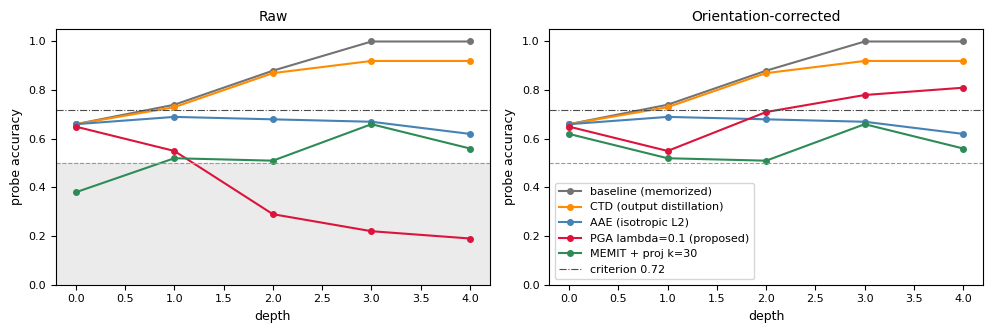

saved fig_orientation_correction.{png,pdf} at 600 dpi


In [10]:
# ---- Figure (600 dpi): the correction applied to the toy method comparison ----
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'savefig.dpi': 600, 'font.size': 9, 'axes.titlesize': 10,
                            'axes.labelsize': 9, 'legend.fontsize': 8,
                            'xtick.labelsize': 8, 'ytick.labelsize': 8})
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
show = ['baseline (memorized)', 'CTD (output distillation)', 'AAE (isotropic L2)',
        'PGA lambda=0.1 (proposed)', 'MEMIT + proj k=30']
colors = ['0.45', 'darkorange', 'steelblue', 'crimson', 'seagreen']
xs = list(range(5))
for name, col in zip(show, colors):
    axes[0].plot(xs, TOY[name], marker='o', ms=4, color=col, label=name)
    axes[1].plot(xs, corrected_vec(TOY[name]), marker='o', ms=4, color=col, label=name)
for ax, title in zip(axes, ['Raw', 'Orientation-corrected']):
    ax.axhline(CRITERION, color='0.3', lw=0.8, ls='-.', label='criterion 0.72')
    ax.axhline(0.5, color='0.6', lw=0.8, ls='--')
    ax.set_xlabel('depth'); ax.set_ylabel('probe accuracy')
    ax.set_ylim(0, 1.05); ax.set_title(title)
axes[0].axhspan(0, 0.5, color='0.92', zorder=0)
axes[1].legend(loc='lower left', ncol=1)
plt.tight_layout()
for ext in ('png', 'pdf'):
    plt.savefig(f'fig_orientation_correction.{ext}', dpi=600, bbox_inches='tight')
plt.show()
print('saved fig_orientation_correction.{png,pdf} at 600 dpi')


In [11]:
# ---- Persist every corrected number for cross-checking against the manuscript ----
import json
audit = {
  'toy_methods': {k: {'raw': v, 'corrected': corrected_vec(v),
                      'raw_max': max(v), 'corrected_max': max(corrected_vec(v)),
                      'meets_criterion_raw': bool(max(v) <= CRITERION),
                      'meets_criterion_corrected': bool(max(corrected_vec(v)) <= CRITERION)}
                  for k, v in TOY.items()},
  'toy_robustness': {k: {'raw': v, 'corrected': corrected_vec(v),
                         'raw_max': max(v), 'corrected_max': max(corrected_vec(v))}
                     for k, v in TOY_ROBUST.items()},
  'toy_robustness_worst': {'raw': raw_worst, 'corrected': corr_worst},
  'pythia_robustness': {k: {'raw': v, 'corrected': corrected_vec(v),
                            'raw_max': max(v), 'corrected_max': max(corrected_vec(v)),
                            'raw_max_L2_L6': max(v[2:]),
                            'corrected_max_L2_L6': max(corrected_vec(v)[2:])}
                        for k, v in PYTHIA_ROBUST.items()},
  'pythia_robustness_worst': {'raw': pr_raw, 'corrected': pr_corr,
                              'raw_L2_L6': pr_raw_mem, 'corrected_L2_L6': pr_corr_mem},
  'scaling': {arch: {'raw': raw, 'corrected': corrected(raw), 'config': cfg}
              for arch, _, raw, cfg in SCALING},
  'multiseed_L6': {'raw': SEED_L6, 'corrected': corr,
                   'corrected_mean': float(vals.mean()), 'corrected_std': float(vals.std()),
                   'corrected_min': float(vals.min()), 'corrected_max': float(vals.max())},
  'fresh_probe_layers_3_6': {'raw': L36, 'corrected': corrected_vec(L36)},
}
with open('orientation_correction_audit.json', 'w') as f:
    json.dump(audit, f, indent=1)
print('saved -> orientation_correction_audit.json')
print('\nEvery orientation-corrected value quoted in the manuscript appears in this file.')


saved -> orientation_correction_audit.json

Every orientation-corrected value quoted in the manuscript appears in this file.


## Scope of this notebook

This is arithmetic on published values, and it inherits their rounding. The inputs are the
two-decimal per-depth entries printed in the paper's tables, so a corrected value here can differ
from one recomputed from full-precision activations by up to a rounding step, and by up to 1/14 in
the single-run Pythia tables where the underlying grid is coarse. Where a corrected value sits
near the 0.72 criterion, that margin matters and the text says so rather than treating the
comparison as decided.

What this notebook does not do is re-run any model, and it should not be cited as evidence that
the underlying runs are correct. It establishes only that the corrected numbers in the text
follow from the raw numbers in the tables.
